## 3.3 양자 어닐링 (Quantum Annealing)

In [ ]:
%pip install -q qiskit-optimization qiskit-algorithms

In [1]:
# 필요한 라이브러리 불러오기
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler as Sampler  # 호환성 수정(qiskit 2.x): V1 Sampler 제거 → StatevectorSampler(V2) 사용
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 간단한 최적화 문제 정의: x1 + x2 <= 1 제약에서 x1 + 2*x2 최대화
qp = QuadraticProgram()
qp.binary_var('x1')
qp.binary_var('x2')
qp.maximize(linear={'x1': 1, 'x2': 2})
qp.linear_constraint({'x1': 1, 'x2': 1}, '<=', 1)

<LinearConstraint: x1 + x2 <= 1 'c0'>

In [3]:
# 문제를 QUBO 형태로 변환
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)

In [4]:
# Aer 시뮬레이터 백엔드 설정
simulator = AerSimulator()

In [5]:
# QAOA 인스턴스 정의
optimizer = COBYLA(maxiter=100)
sampler = Sampler()
qaoa = QAOA(optimizer=optimizer, reps=1, sampler=sampler)

In [6]:
# QAOA를 이용한 MinimumEigenOptimizer 생성
qaoa_optimizer = MinimumEigenOptimizer(qaoa)

In [7]:
# 최적화 문제 풀기
result = qaoa_optimizer.solve(qubo)
print(result)

fval=-2.0, x1=0.0, x2=1.0, status=SUCCESS


/opt/miniconda3/envs/qml/lib/python3.10/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/opt/miniconda3/envs/qml/lib/python3.10/site-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [8]:
# 최적 해 추출
optimal_solution = result.x
print(f"Optimal solution: x1 = {optimal_solution[0]}, x2 = {optimal_solution[1]}")

Optimal solution: x1 = 0.0, x2 = 1.0


In [9]:
# 최종 상태 시각화
# 최적 파라미터로 QAOA 회로 생성
optimal_params = result.min_eigen_solver_result.optimal_point

In [10]:
# 최적 파라미터로 QAOA 회로 재생성
num_qubits = qubo.get_num_binary_vars()
qaoa_ansatz = QuantumCircuit(num_qubits)
qaoa_ansatz.h(range(num_qubits))
qaoa_ansatz.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [11]:
# QAOA 비용 해밀토니안 추가 (시연용 간단 예시)
for i in range(num_qubits):
    qaoa_ansatz.rz(optimal_params[0], i)
qaoa_ansatz.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

In [12]:
# QAOA 믹서 해밀토니안 추가
for i in range(num_qubits):
    qaoa_ansatz.rx(optimal_params[1], i)
qaoa_ansatz.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=2, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>), clbits=())

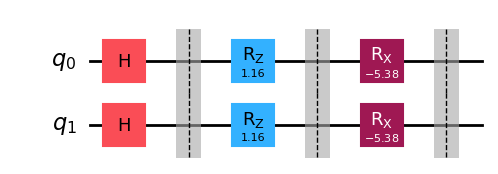

In [13]:
# 회로 트랜스파일 및 시각화
qaoa_ansatz = transpile(qaoa_ansatz, simulator)
qaoa_ansatz.draw('mpl')
plt.show()

In [15]:
# 최종 상태 시뮬레이션
# transpiled_circuit = transpile(qaoa_ansatz, simulator)
# final_result = simulator.run(transpiled_circuit, shots=1024).result()
# counts = final_result.get_counts(transpiled_circuit)
# plot_histogram(counts)
# plt.show()